In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize']=(10,6)

In [ ]:
balls_df=pd.read_csv("/content/IPL Ball-by-Ball 2008-2020.csv")
balls_df

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193463,1237181,1,12,5,RR Pant,SS Iyer,NM Coulter-Nile,0,0,0,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians
193464,1237181,1,12,6,RR Pant,SS Iyer,NM Coulter-Nile,1,0,1,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians
193465,1237181,1,13,1,RR Pant,SS Iyer,KH Pandya,0,1,1,0,0,NaN,NaN,NaN,wides,Delhi Capitals,Mumbai Indians
193466,1237181,1,13,2,RR Pant,SS Iyer,KH Pandya,1,0,1,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians


In [ ]:
matches_df=pd.read_csv("/content/IPL Matches 2008-2020.csv")
matches_df

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,1216547,Dubai,2020-09-28,AB de Villiers,Dubai International Cricket Stadium,0,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,tie,NaN,Y,NaN,Nitin Menon,PR Reiffel
812,1237177,Dubai,2020-11-05,JJ Bumrah,Dubai International Cricket Stadium,0,Mumbai Indians,Delhi Capitals,Delhi Capitals,field,Mumbai Indians,runs,57.0,N,NaN,CB Gaffaney,Nitin Menon
813,1237178,Abu Dhabi,2020-11-06,KS Williamson,Sheikh Zayed Stadium,0,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,wickets,6.0,N,NaN,PR Reiffel,S Ravi
814,1237180,Abu Dhabi,2020-11-08,MP Stoinis,Sheikh Zayed Stadium,0,Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,runs,17.0,N,NaN,PR Reiffel,S Ravi


In [ ]:
matches_df['date']=pd.to_datetime(matches_df['date'])
matches_df['season']=matches_df['date'].dt.year
matches_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               816 non-null    int64         
 1   city             803 non-null    object        
 2   date             816 non-null    datetime64[ns]
 3   player_of_match  812 non-null    object        
 4   venue            816 non-null    object        
 5   neutral_venue    816 non-null    int64         
 6   team1            816 non-null    object        
 7   team2            816 non-null    object        
 8   toss_winner      816 non-null    object        
 9   toss_decision    816 non-null    object        
 10  winner           812 non-null    object        
 11  result           812 non-null    object        
 12  result_margin    799 non-null    float64       
 13  eliminator       812 non-null    object        
 14  method           19 non-null     object   

In [ ]:
matches_df['season']=matches_df['date'].dt.year
matches_df

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,season
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri,2008
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar,2008
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper,2008
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,1216547,Dubai,2020-09-28,AB de Villiers,Dubai International Cricket Stadium,0,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,tie,NaN,Y,NaN,Nitin Menon,PR Reiffel,2020
812,1237177,Dubai,2020-11-05,JJ Bumrah,Dubai International Cricket Stadium,0,Mumbai Indians,Delhi Capitals,Delhi Capitals,field,Mumbai Indians,runs,57.0,N,NaN,CB Gaffaney,Nitin Menon,2020
813,1237178,Abu Dhabi,2020-11-06,KS Williamson,Sheikh Zayed Stadium,0,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,wickets,6.0,N,NaN,PR Reiffel,S Ravi,2020
814,1237180,Abu Dhabi,2020-11-08,MP Stoinis,Sheikh Zayed Stadium,0,Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,runs,17.0,N,NaN,PR Reiffel,S Ravi,2020


/tmp/ipykernel_470/1117485152.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


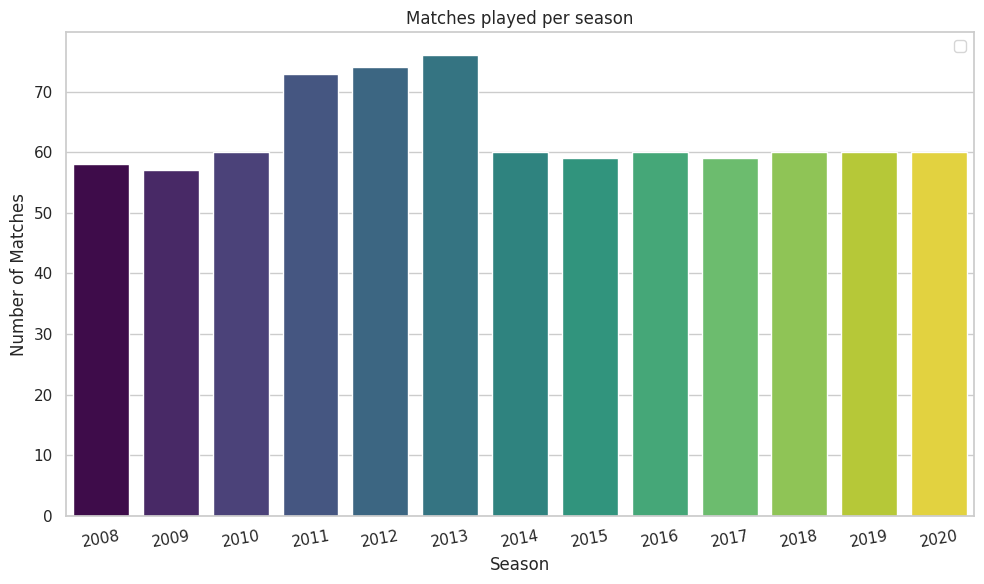

In [ ]:
#Q1.What was the count of matches played in each season?
##ANSWER:-
matches_per_season=matches_df['season'].value_counts().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=matches_per_season.index,y=matches_per_season.values,palette="viridis",hue=matches_per_season.index,legend=False)
plt.legend(loc='upper right')
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.title("Matches played per season")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_470/3205977838.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


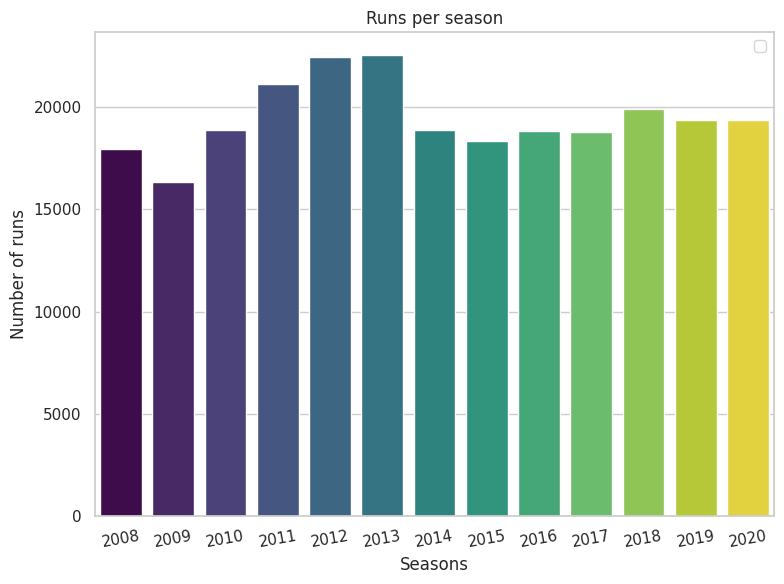

In [ ]:
#Q2How many runs were scored in each season?
##ANSWER:-
merged_df = balls_df.merge(matches_df[["id","season"]],on='id')
runs_per_season = merged_df.groupby('season')['total_runs'].sum()
plt.figure(figsize=(8,6))
sns.barplot(x=runs_per_season.index,y=runs_per_season.values,palette="viridis",hue=runs_per_season.index,legend=False)
plt.legend(loc='upper right')
plt.xlabel("Seasons")
plt.ylabel("Number of runs")
plt.title("Runs per season")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_470/2851563686.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


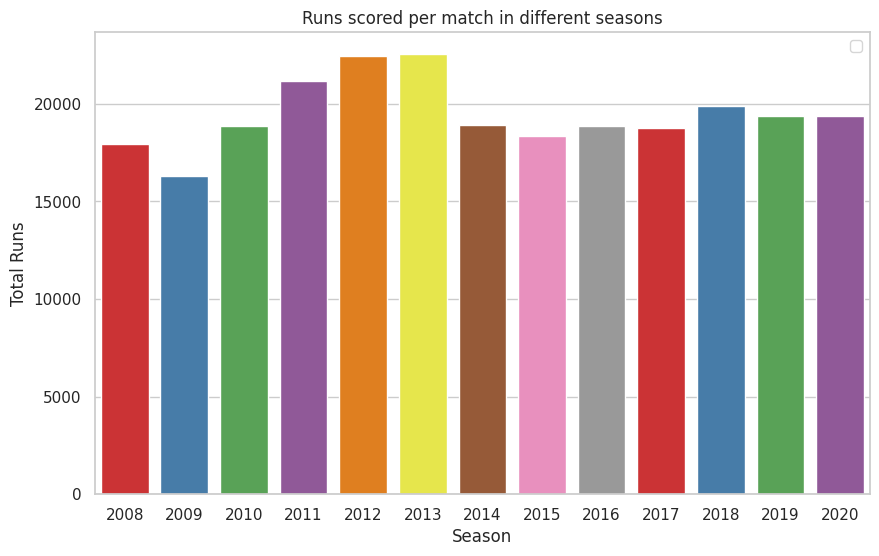

In [ ]:
#Q3.What were the runs scored per match in different seasons?
##ANSWER:-
runs_per_season=merged_df.groupby('season')['total_runs'].sum()
sns.barplot(x=runs_per_season.index,y=runs_per_season.values,palette='Set1',hue=runs_per_season.index,legend=False)
plt.legend(loc='upper right')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.title('Runs scored per match in different seasons')

plt.show()

In [ ]:
#Q4.Who has umpired the most?
##ANSWER:-
umpires=matches_df['umpire1']= matches_df['umpire2'].value_counts().idxmax()
umpires

'S Ravi'

In [ ]:
#Q5.Which team has won the most tosses?
##ANSWER:-
toss_decision_count=matches_df['toss_winner'].value_counts().idxmax()

toss_decision_count


'Mumbai Indians'

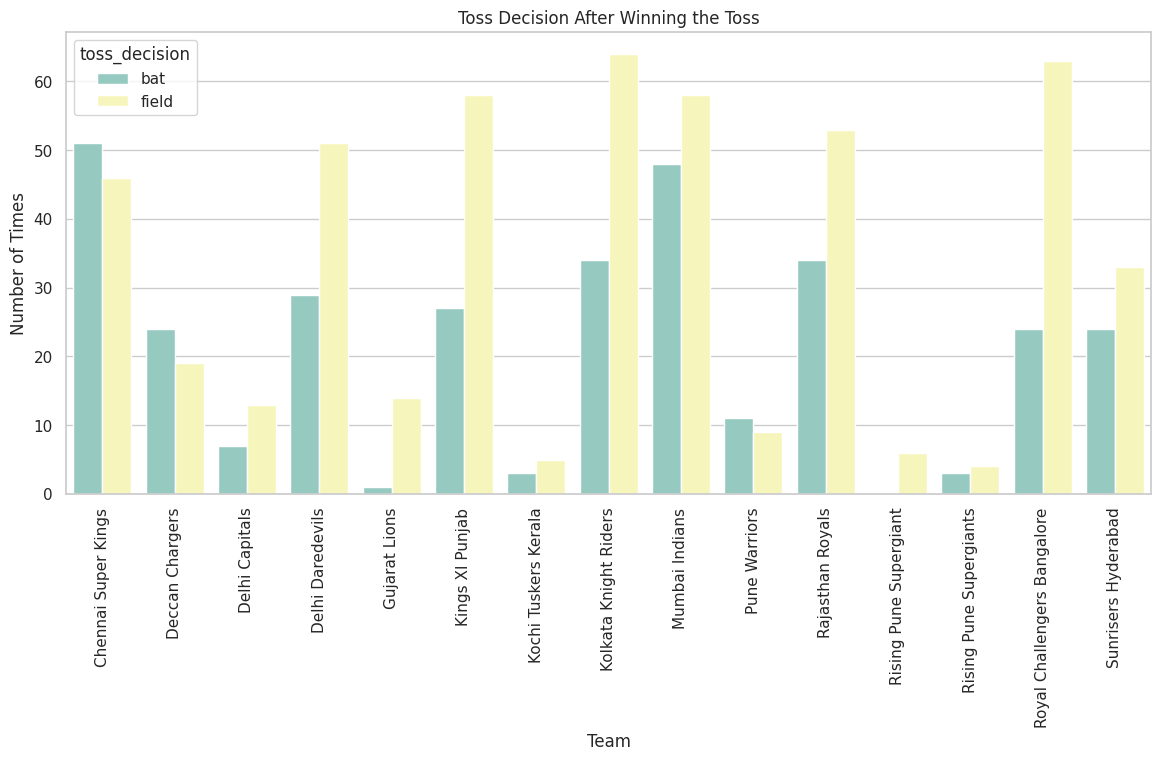

In [ ]:
#Q6.What does the team decide after winning the toss?
##ANSWER:-
toss_decision_count = (
    matches_df.groupby(['toss_winner', 'toss_decision'])
    .size()
    .reset_index(name='Count')
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=toss_decision_count,
    x='toss_winner',
    y='Count',
    hue='toss_decision',
    palette='Set3'
)

plt.xticks(rotation=90)
plt.xlabel('Team')
plt.ylabel('Number of Times')
plt.title('Toss Decision After Winning the Toss')
plt.show()

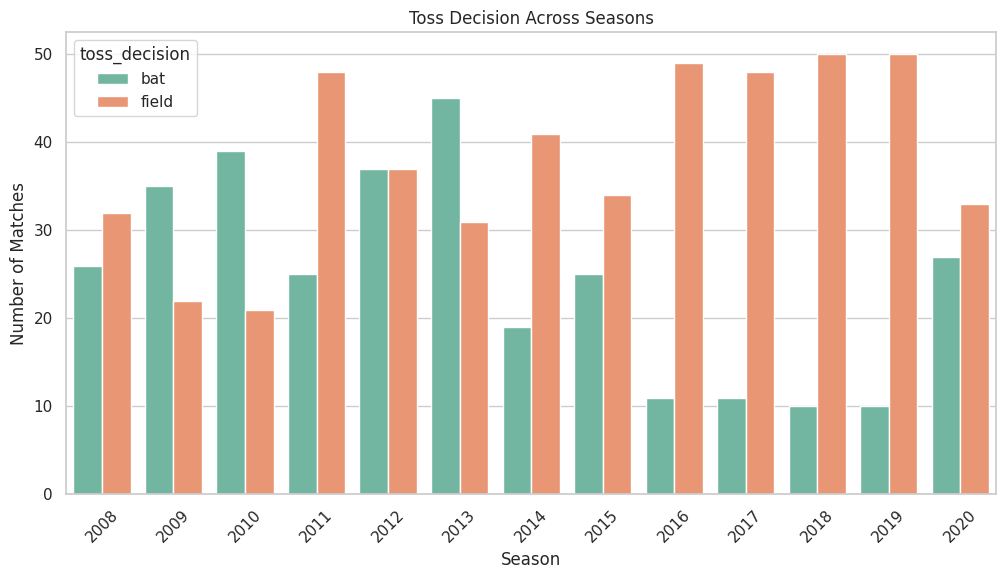

In [ ]:
#Q7.How does the toss decision vary across seasons?
#ANSWER:-
toss_decision_count = (
    matches_df.groupby(['season', 'toss_decision'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=toss_decision_count,
    x='season',
    y='count',
    hue='toss_decision',
    palette='Set2'
)

plt.title("Toss Decision Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()


Matches where toss winner won the match: 418
Total matches: 816
Percentage: 51.23%


(np.float64(-1.0999999705496548),
 np.float64(1.0999998531471546),
 np.float64(-1.0999998709075656),
 np.float64(1.0999999938527412))

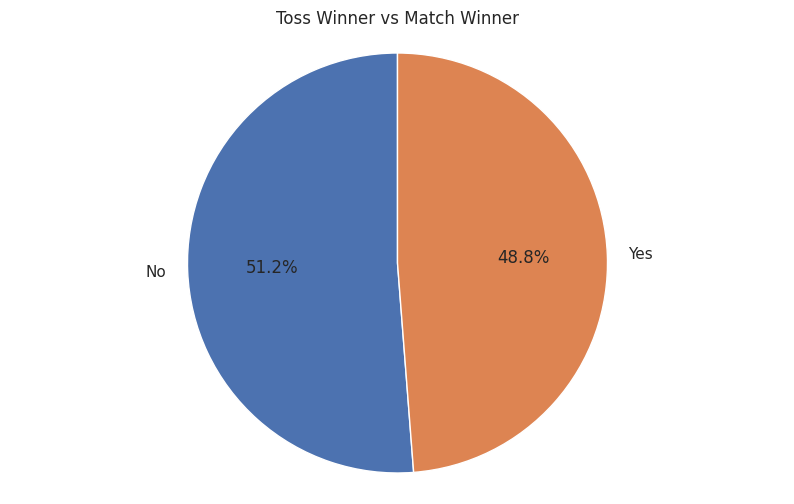

In [ ]:
#Q8.Does winning the toss imply winning the game?
##NASER:-
# Number of matches where the toss winner also won the match
toss_match_win = (matches_df['toss_winner'] == matches_df['winner']).sum()

# Total number of matches
total_matches = len(matches_df)

# Percentage of matches
percentage = (toss_match_win / total_matches) * 100

print("Matches where toss winner won the match:", toss_match_win)
print("Total matches:", total_matches)
print("Percentage: {:.2f}%".format(percentage))
plt.pie([toss_match_win, total_matches - toss_match_win], labels=['No', 'Yes'], autopct='%1.1f%%', startangle=90,)
plt.title('Toss Winner vs Match Winner')
plt.axis('equal')

Number of times the chasing team won the match: 447


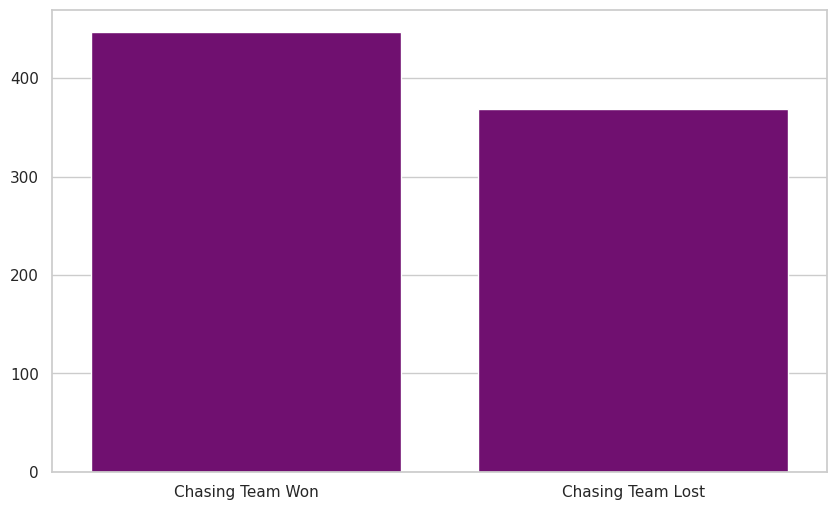

In [ ]:
#Q9.How many times has the chasing team won the match?
##ANSWER:-
# Find the chasing team
matches_df['chasing_team'] = matches_df.apply(
    lambda row:
        row['team2'] if (row['toss_winner'] == row['team1'] and row['toss_decision'] == 'bat') or
                         (row['toss_winner'] == row['team2'] and row['toss_decision'] == 'field')
        else row['team1'],
    axis=1
)

# Count how many times the chasing team won
chasing_wins = (matches_df['chasing_team'] == matches_df['winner']).sum()

print("Number of times the chasing team won the match:", chasing_wins)
sns.barplot(x=['Chasing Team Won', 'Chasing Team Lost'], y=[chasing_wins, len(matches_df) - chasing_wins],color='Purple')
plt.show()

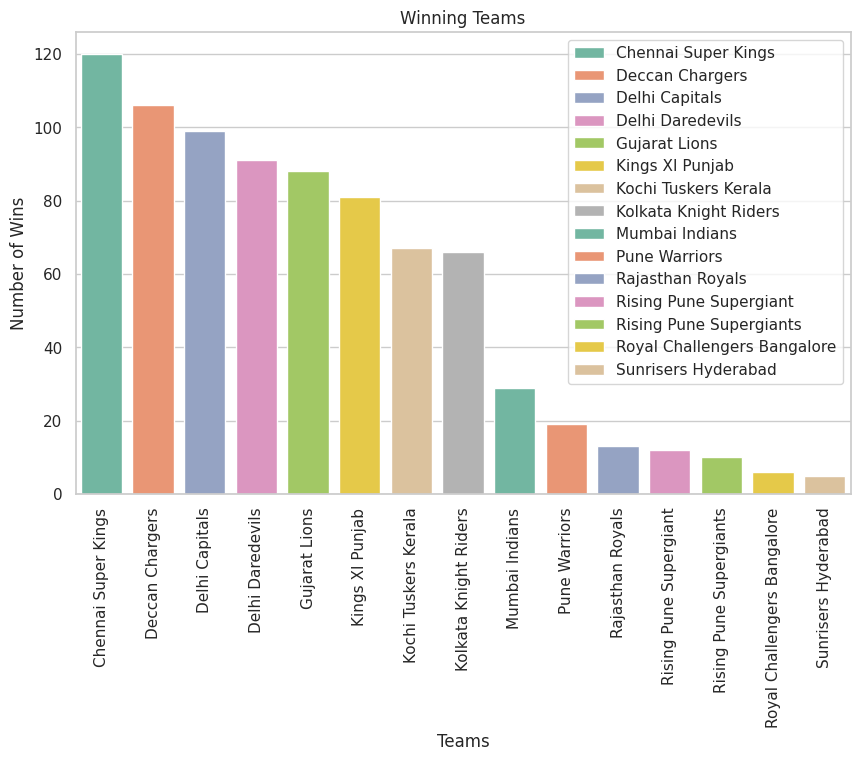

In [ ]:
#Q10.Which all teams had won this tournament?
##ANSWER:-
winning_teams = sorted(matches_df['winner'].value_counts().index)
winning_teams
sns.barplot(x=winning_teams,y=matches_df['winner'].value_counts().values,palette='Set2',hue=winning_teams,legend=True)
plt.title('Winning Teams')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.xticks(rotation=90)
plt.show()


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Mumbai Indians'),
  Text(1, 0, 'Royal Challengers Bangalore'),
  Text(2, 0, 'Kolkata Knight Riders'),
  Text(3, 0, 'Kings XI Punjab'),
  Text(4, 0, 'Chennai Super Kings'),
  Text(5, 0, 'Rajasthan Royals'),
  Text(6, 0, 'Delhi Daredevils'),
  Text(7, 0, 'Sunrisers Hyderabad'),
  Text(8, 0, 'Deccan Chargers'),
  Text(9, 0, 'Pune Warriors'),
  Text(10, 0, 'Delhi Capitals'),
  Text(11, 0, 'Gujarat Lions'),
  Text(12, 0, 'Rising Pune Supergiant'),
  Text(13, 0, 'Kochi Tuskers Kerala'),
  Text(14, 0, 'Rising Pune Supergiants')])

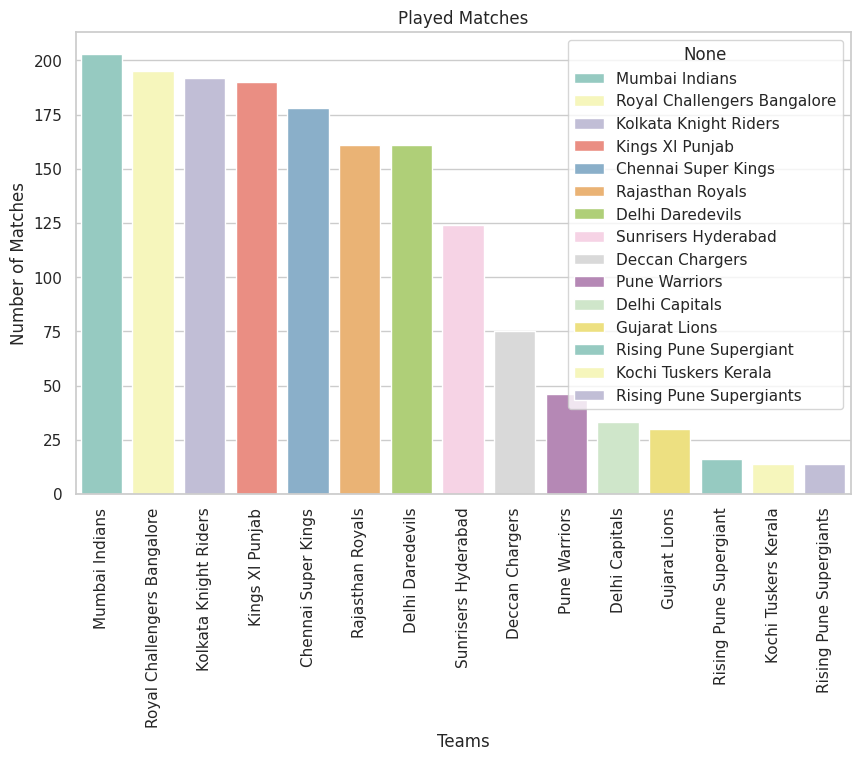

In [ ]:
#Q11.Which team has played the most number of matches?
##ANSWER:-
team_matches=pd.concat([matches_df['team1'],matches_df['team2']])
plt.figure(figsize=(10,6))
sns.barplot(x=team_matches.value_counts().index,y=team_matches.value_counts().values,palette='Set3',hue=team_matches.value_counts().index,legend=True)
plt.title('Played Matches')
plt.xlabel('Teams')
plt.ylabel('Number of Matches')
plt.xticks(rotation=90)

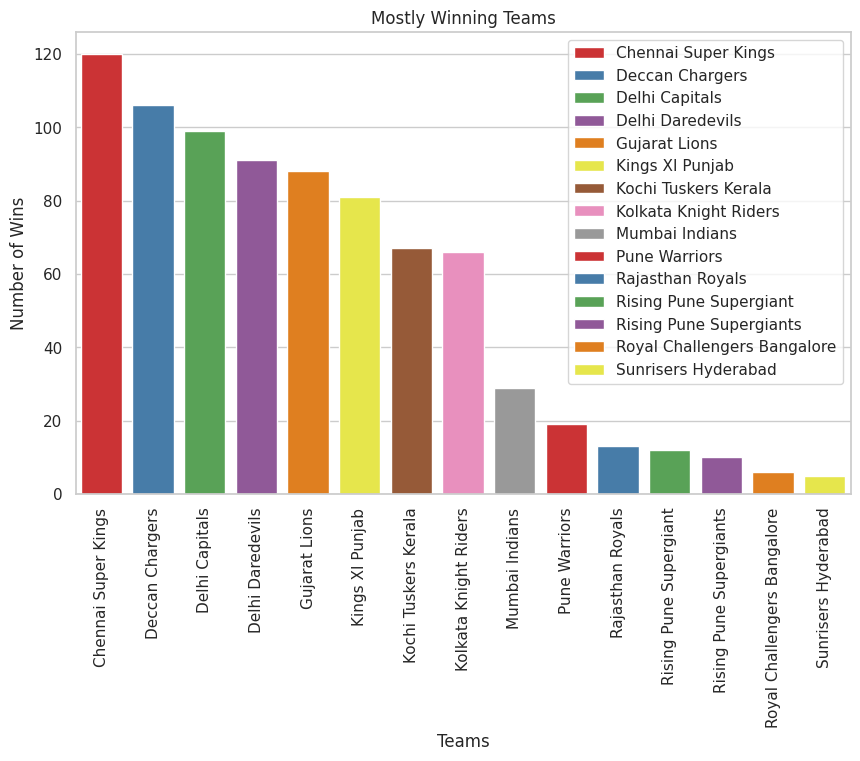

In [ ]:
#Q12.Which team has won the most number of times?
##ANSWER:-
winning_teams = sorted(matches_df['winner'].value_counts().index)
winning_teams
plt.figure(figsize=(10,6))
sns.barplot(x=winning_teams,y=matches_df['winner'].value_counts().values,palette='Set1',hue=winning_teams,legend=True)
plt.title('Mostly Winning Teams')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.xticks(rotation=90)
plt.show()

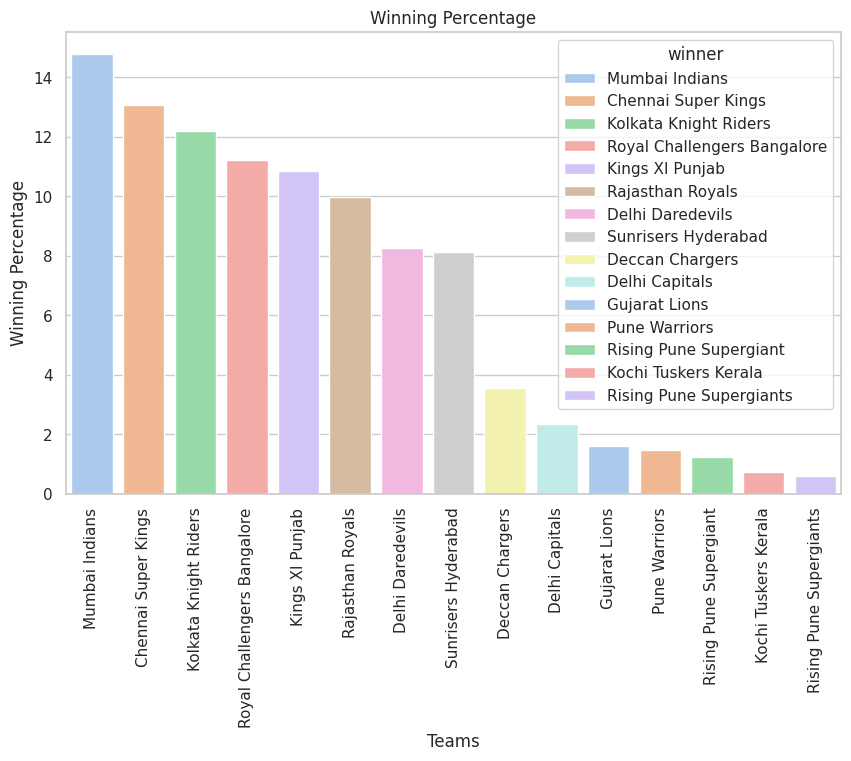

In [ ]:
#Q13.Which team has the highest winning percentage?
##ANSWER:-
winning_percentage = (matches_df['winner'].value_counts()/matches_df['winner'].value_counts().sum())*100
winning_percentage.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=winning_percentage.index,y=winning_percentage.values,palette='pastel',hue=winning_percentage.index,legend=True)
plt.title('Winning Percentage')
plt.xlabel('Teams')
plt.ylabel('Winning Percentage')
plt.xticks(rotation=90)
plt.show()

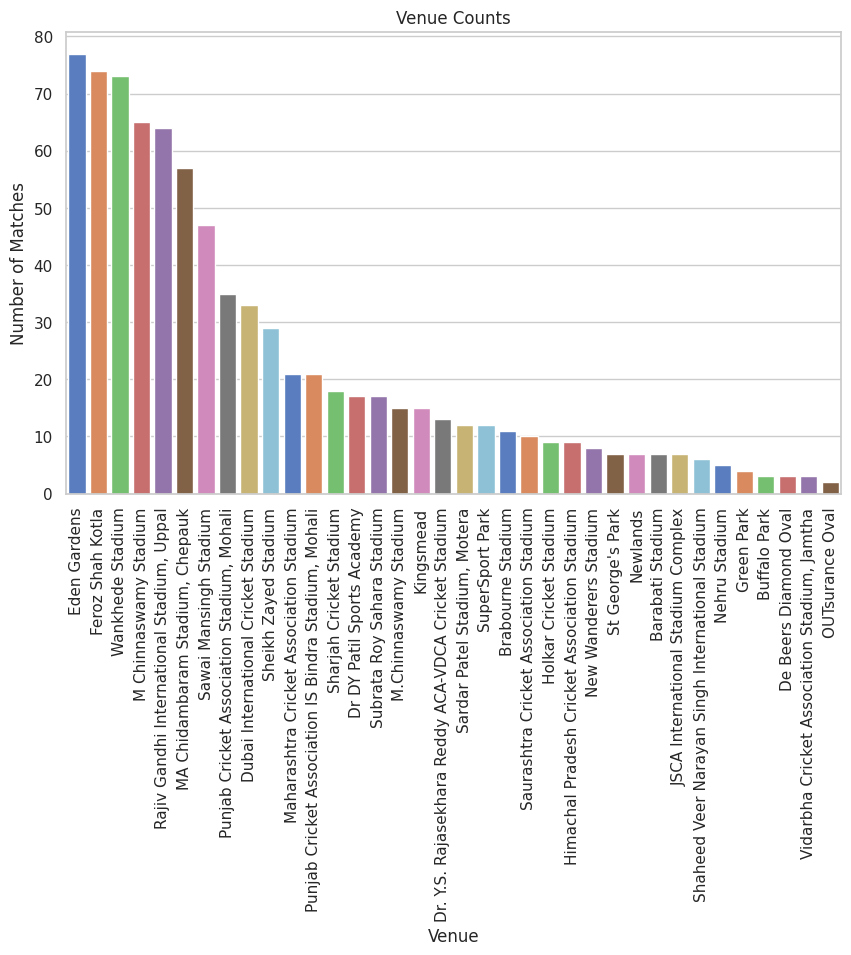

In [ ]:
#Q14.is there any lucky venue for a particular team?
##ANSWER:-
venue_counts = matches_df['venue'].value_counts()
venue_counts.sort_values(ascending=False)
sns.barplot(x=venue_counts.index,y=venue_counts.values,palette='muted',hue=venue_counts.index,legend=False)
plt.title('Venue Counts')
plt.xlabel('Venue')
plt.ylabel('Number of Matches')
plt.xticks(rotation=90)
plt.show()

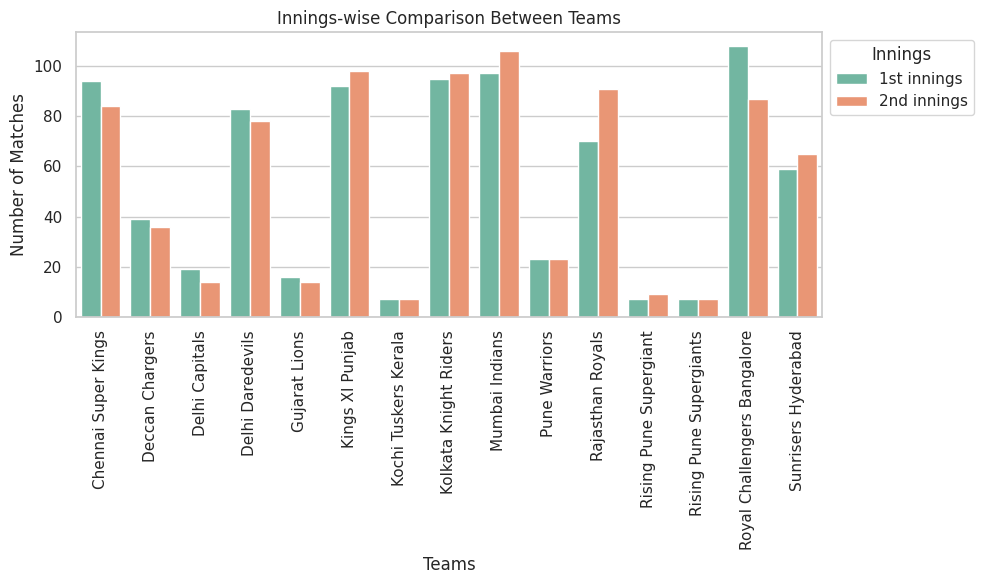

In [ ]:
#Q15.Innings wise comparison between teams
##ANSWER:-
# Create DataFrame
inning_comparision = pd.DataFrame({
    '1st innings': matches_df['team1'].value_counts(),
    '2nd innings': matches_df['team2'].value_counts()
}).fillna(0).astype(int)

# Convert wide format to long format
inning_comparision = inning_comparision.reset_index()
inning_comparision.rename(columns={'index': 'Team'}, inplace=True)

inning_comparision = inning_comparision.melt(
    id_vars='Team',
    var_name='Innings',
    value_name='Matches'
)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=inning_comparision,
    x='Team',
    y='Matches',
    hue='Innings',
    palette='Set2'
)

plt.title("Innings-wise Comparison Between Teams")
plt.xlabel("Teams")
plt.ylabel("Number of Matches")
plt.xticks(rotation=90)
plt.legend(title="Innings",loc='upper left',bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

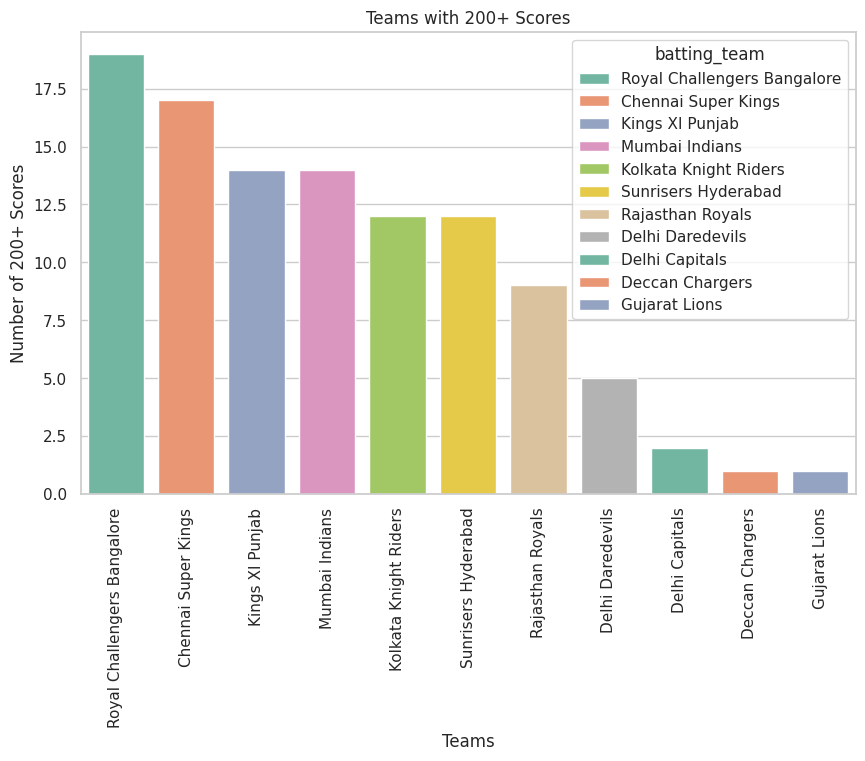

In [ ]:
#Q16.Which team has scored the most number of 200+ scores?
##ANSWER:-
team_socres=(balls_df.groupby(['id','inning','batting_team']))['total_runs'].sum().reset_index()
team_socres=team_socres[team_socres['total_runs']>=200]
team_socres
sns.barplot(x=team_socres['batting_team'].value_counts().index,y=team_socres['batting_team'].value_counts().values,palette='Set2',hue=team_socres['batting_team'].value_counts().index,legend=True)
plt.title('Teams with 200+ Scores')
plt.xlabel('Teams')
plt.ylabel('Number of 200+ Scores')
plt.xticks(rotation=90)
plt.show()

Team that conceded the most 200+ scores: Kings XI Punjab
Number of times: 20


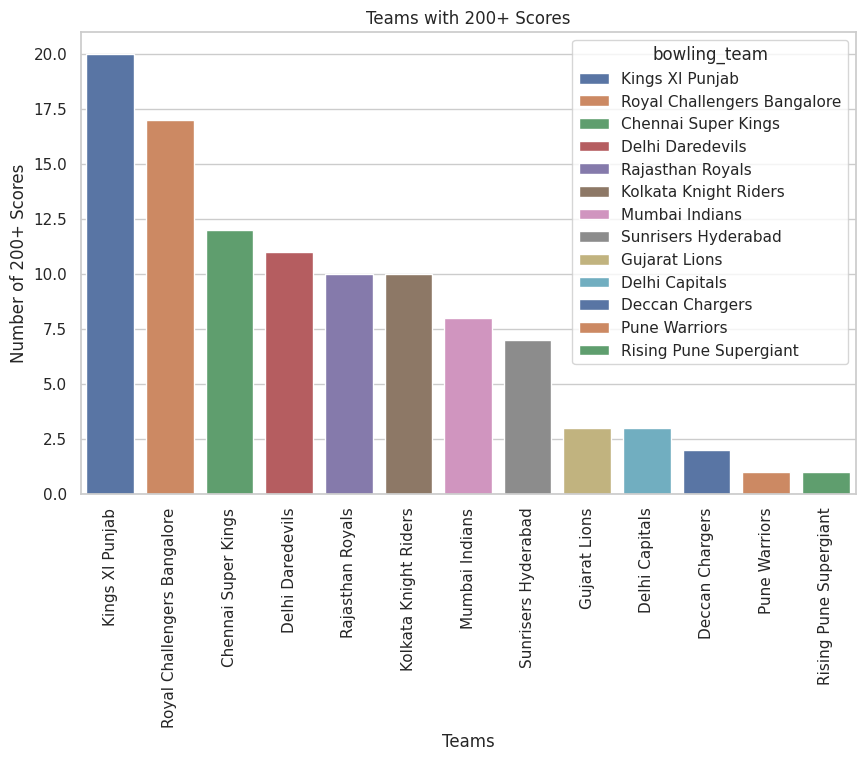

In [ ]:
#Q17.Which team has conceded 200+ scores the most?
##ANSWER:-
# Calculate total runs scored against each bowling team in every innings
team_conceded = (
    balls_df
    .groupby(['id', 'inning', 'bowling_team'])['total_runs']
    .sum()
    .reset_index()
)

# Filter innings where 200 or more runs were conceded
team_conceded = team_conceded[team_conceded['total_runs'] >= 200]

# Count how many times each bowling team conceded 200+
conceded_200_counts = team_conceded['bowling_team'].value_counts()

# Print the answer
print("Team that conceded the most 200+ scores:", conceded_200_counts.idxmax())
print("Number of times:", conceded_200_counts.max())
sns.barplot(x=conceded_200_counts.index,y=conceded_200_counts.values,palette='deep',hue=conceded_200_counts.index,legend=True)
plt.title('Teams with 200+ Scores')
plt.xlabel('Teams')
plt.ylabel('Number of 200+ Scores')
plt.xticks(rotation=90)
plt.show()

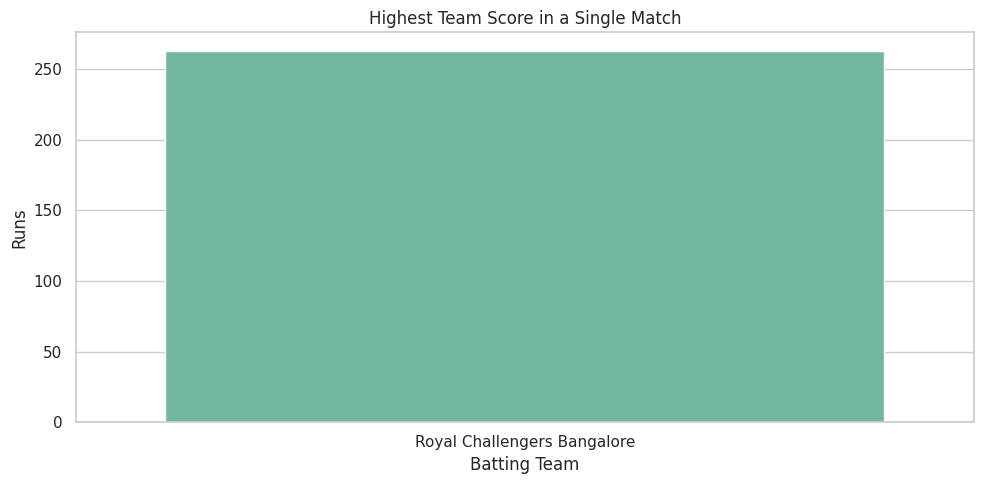

In [ ]:
#Q18.What was the highest run scored by a team in a single match?
##ANSWER:-
heighest_runs=balls_df.groupby(['id','inning','batting_team'])['total_runs'].sum().reset_index()
heigest_runs=heighest_runs.sort_values(by='total_runs',ascending=False)
heigest_runs.iloc[0]
plt.figure(figsize=(10,5))

sns.barplot(
    data=heigest_runs.iloc[[0]],
    x='batting_team',
    y='total_runs',
    palette='Set2',
    hue='batting_team',
    legend=False
)

plt.title("Highest Team Score in a Single Match")
plt.xlabel("Batting Team")
plt.ylabel("Runs")
plt.tight_layout()

plt.show()

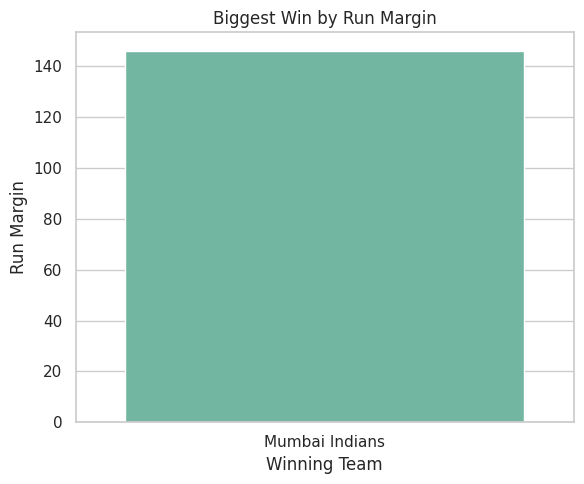

In [ ]:
#Q19.Which is the biggest win in terms of run margin?
##ANSWER:-
run_margin = matches_df[matches_df['result'] == 'runs']

run_margin = run_margin.sort_values(by='result_margin', ascending=False)

run_margin[['season', 'team1', 'team2', 'winner', 'result_margin']].head(1)

import matplotlib.pyplot as plt
import seaborn as sns

# Get the biggest win
biggest_win = run_margin.iloc[[0]]

plt.figure(figsize=(6,5))

sns.barplot(
    data=biggest_win,
    x='winner',
    y='result_margin',
    palette='Set2',
    hue='winner',
    legend=False
)

plt.title("Biggest Win by Run Margin")
plt.xlabel("Winning Team")
plt.ylabel("Run Margin")

plt.tight_layout()
plt.show()

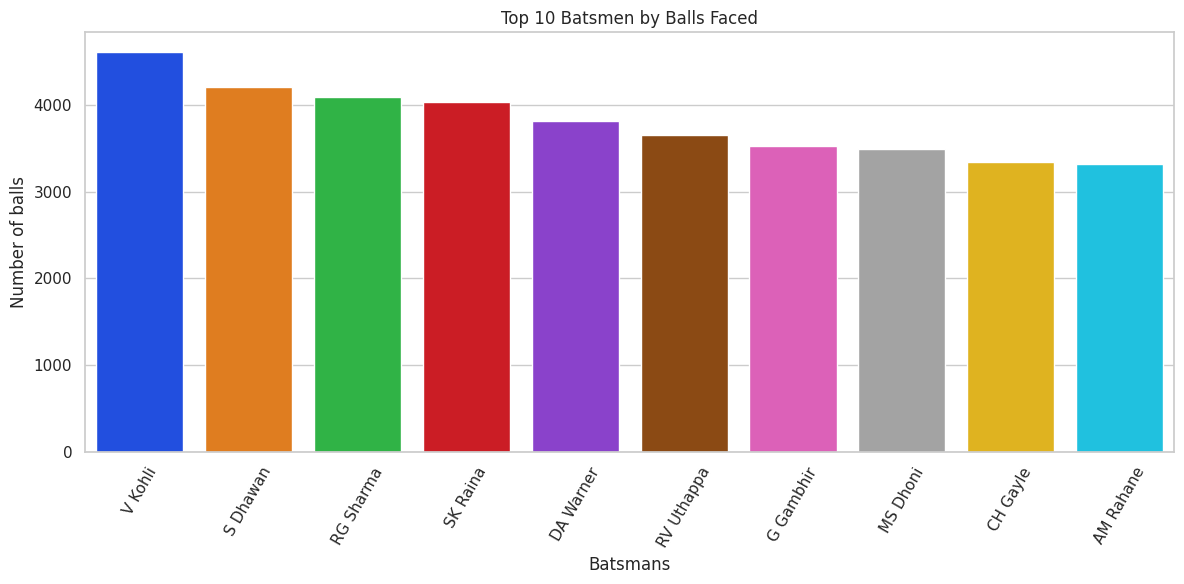

In [ ]:
#Q20.Which batsmen have played the most number of balls?
##ANSWER:
# Q20. Which batsmen have played the most number of balls?

balls_faced = (
    balls_df.groupby('batsman')
    .size()
    .reset_index(name='balls_faced')
)

balls_faced = balls_faced.sort_values(by='balls_faced', ascending=False)

balls_faced.head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

top10 = balls_faced.head(10)

sns.barplot(
    data=top10,
    x='batsman',
    y='balls_faced',
    palette='bright',
    hue='batsman',
    legend=False
)

plt.title("Top 10 Batsmen by Balls Faced")
plt.xlabel("Batsmans")
plt.ylabel("Number of balls")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

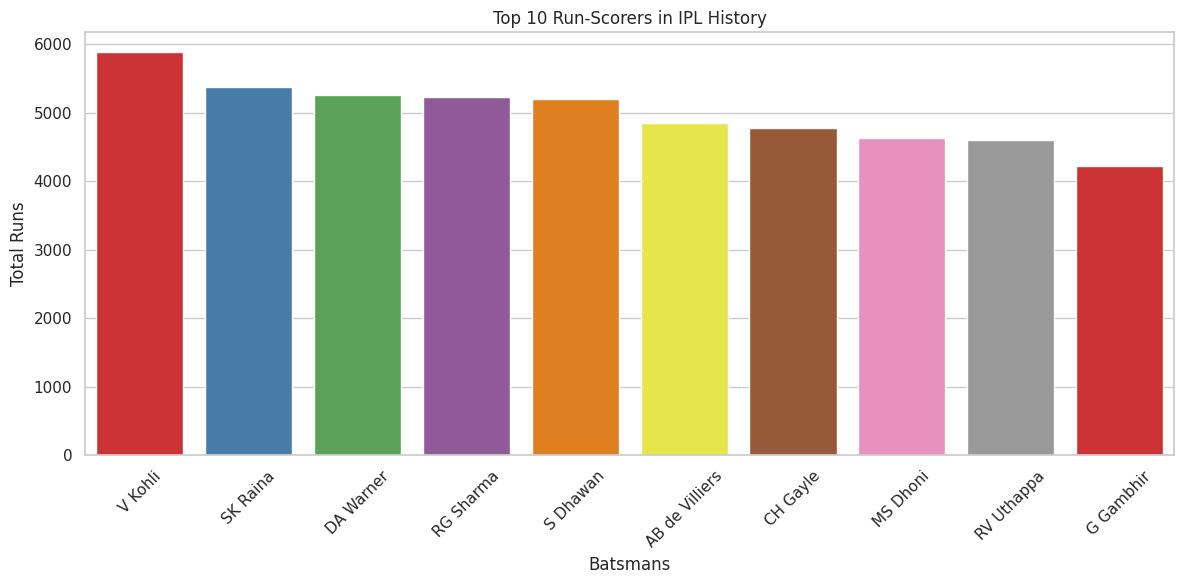

In [ ]:
#Q21.Who are the leading run-scorers of all time?
##ANSWER:-
leading_runs= balls_df.groupby('batsman')['batsman_runs'].sum().reset_index()
leading_runs = leading_runs.sort_values(by='batsman_runs', ascending=False)
leading_runs.head(10)
import matplotlib.pyplot as plt
import seaborn as sns

top10 = leading_runs.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='batsman',
    y='batsman_runs',
    palette='Set1',
    hue='batsman',
    legend=False
)

plt.title("Top 10 Run-Scorers in IPL History")
plt.xlabel("Batsmans")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

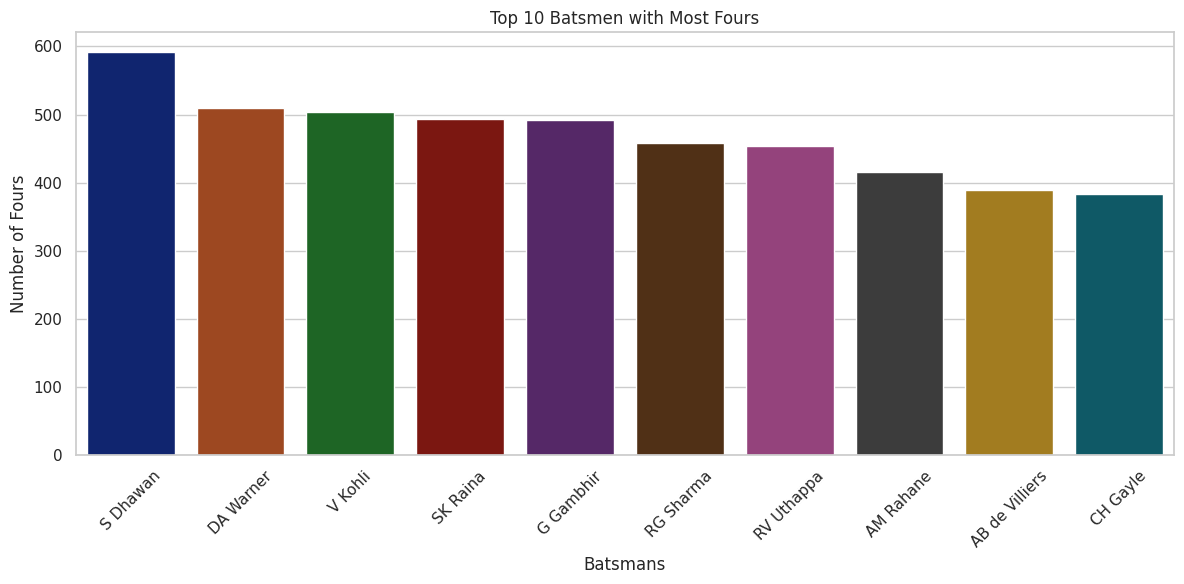

In [ ]:
#Q22.Who has hit the most number of 4's?
##ANSWER:-
fours=balls_df[balls_df['batsman_runs']==4]
most_fours=(fours.groupby('batsman').size().reset_index(name='fours'))
most_fours=most_fours.sort_values(by='fours',ascending=False)
most_fours.head(10)

top10 = most_fours.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='batsman',
    y='fours',
    palette='dark',
    hue='batsman',
    legend=False
)

plt.title("Top 10 Batsmen with Most Fours")
plt.xlabel("Batsmans")
plt.ylabel("Number of Fours")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

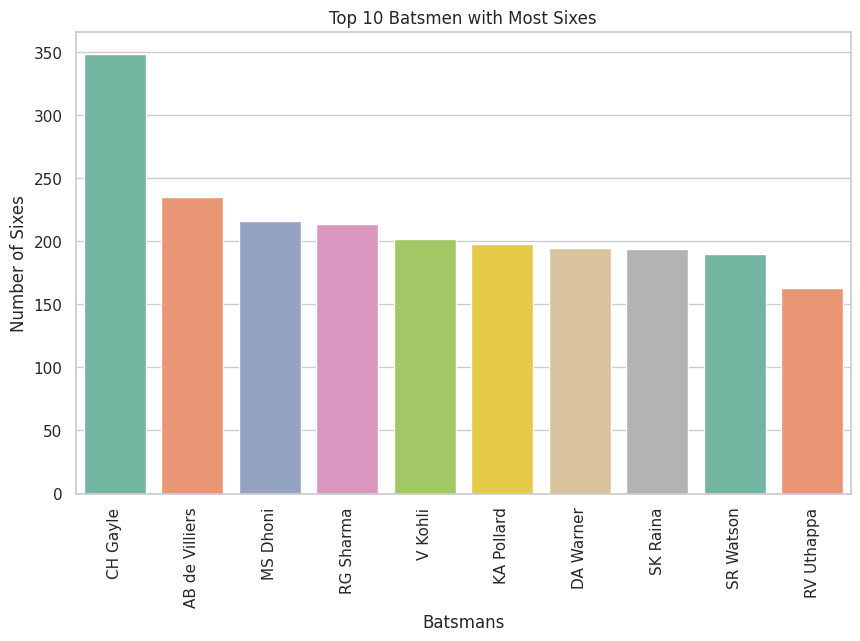

In [ ]:
#Q23.Who has hit the most number of 6's?
##ANSWER:-
sixes=balls_df[balls_df['batsman_runs']==6]
most_sixes=(sixes.groupby('batsman').size().reset_index(name='sixes'))
most_sixes=most_sixes.sort_values(by='sixes',ascending=False)
most_sixes
sns.barplot(x=most_sixes['batsman'].head(10),y=most_sixes['sixes'].head(10),palette='Set3',hue=most_sixes['batsman'].head(10),legend=False)
plt.title('Top 10 Batsmen with Most Sixes')
plt.xlabel('Batsmans')
plt.ylabel('Number of Sixes')
plt.xticks(rotation=90)
plt.show()


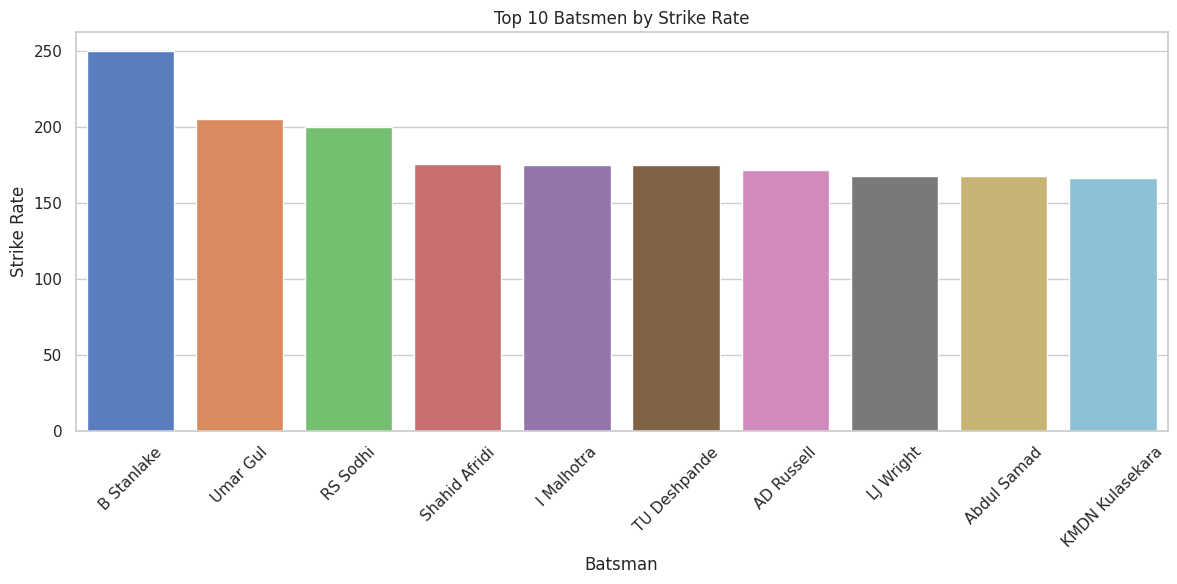

In [ ]:
#Q24.Who has the highest strike rate?
##ANSWER:-
# Total runs scored by each batsman
runs = balls_df.groupby('batsman')['batsman_runs'].sum()

# Total balls faced by each batsman
balls = balls_df.groupby('batsman').size()

# Combine both into a DataFrame
strike_rate = pd.DataFrame({
    'Runs': runs,
    'Balls': balls
})

# Calculate strike rate
strike_rate['Strike_Rate'] = (strike_rate['Runs'] / strike_rate['Balls']) * 100

# Sort by strike rate
strike_rate = strike_rate.sort_values(by='Strike_Rate', ascending=False)

# Display top 10
strike_rate.head(10)

import matplotlib.pyplot as plt
import seaborn as sns

top10 = strike_rate.head(10).reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='batsman',
    y='Strike_Rate',
    palette='muted',
    hue='batsman',
    legend=False
)

plt.title("Top 10 Batsmen by Strike Rate")
plt.xlabel("Batsman")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

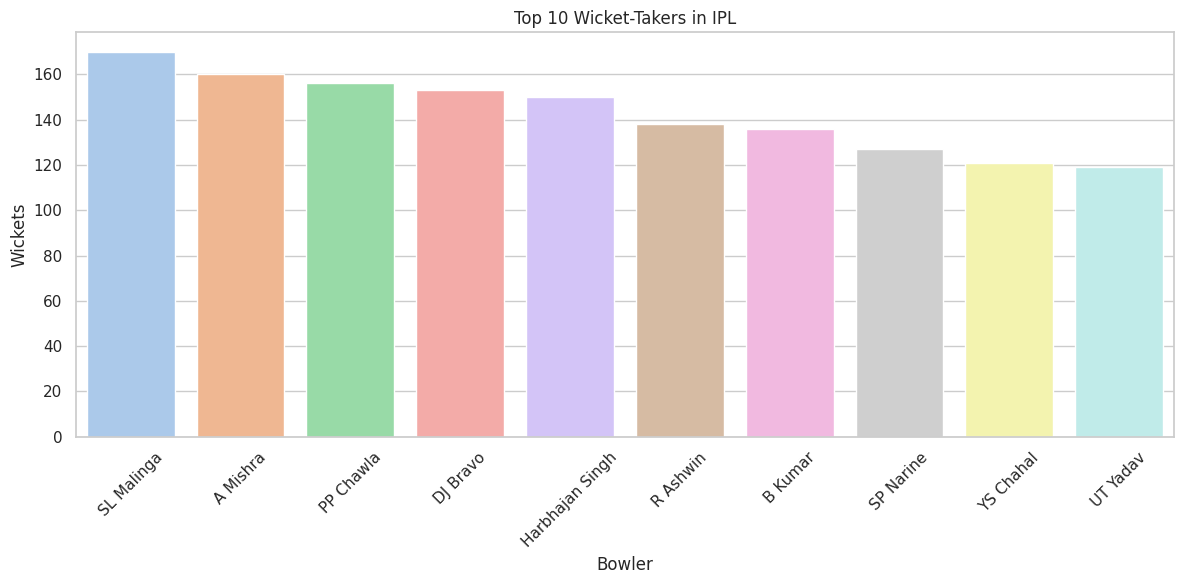

In [ ]:
#Q25.Who is the leading wicket-taker?
##ANSWER:-
# Exclude run outs
wickets = balls_df[
    (balls_df['is_wicket'] == 1) &
    (balls_df['dismissal_kind'] != 'run out')
]

# Count wickets taken by each bowler
leading_wicket_taker = (
    wickets.groupby('bowler')
    .size()
    .reset_index(name='Wickets')
)

# Sort in descending order
leading_wicket_taker = leading_wicket_taker.sort_values(
    by='Wickets',
    ascending=False
)

# Top 10 wicket-takers
leading_wicket_taker.head(10)

import matplotlib.pyplot as plt
import seaborn as sns

top10 = leading_wicket_taker.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='bowler',
    y='Wickets',
    palette='pastel',
    hue='bowler',
    legend=False
)

plt.title("Top 10 Wicket-Takers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

        Stadium  Matches
0  Eden Gardens       77


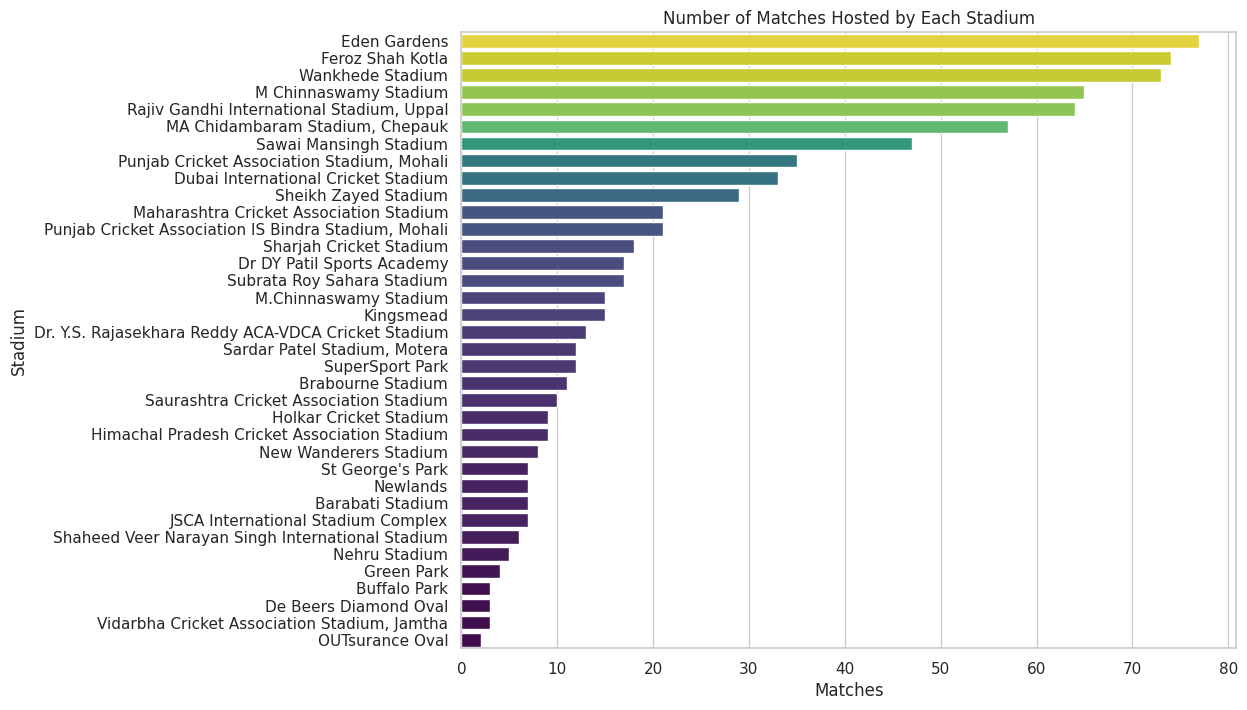

In [ ]:
#Q26.Which stadium has hosted the most number of matches?
##ANSWER:-
stadium_matches = matches_df['venue'].value_counts().reset_index()
stadium_matches.columns = ['Stadium', 'Matches']
stadium_matches = stadium_matches.sort_values(by='Matches', ascending=False)

print(stadium_matches.head(1))
stadium_matches = matches_df['venue'].value_counts().reset_index()
stadium_matches.columns = ['Stadium', 'Matches']

plt.figure(figsize=(10,8))
sns.barplot(data=stadium_matches, x='Matches', y='Stadium', palette='viridis',hue='Matches',legend=False)

plt.title('Number of Matches Hosted by Each Stadium')
plt.xlabel('Matches')
plt.ylabel('Stadium')
plt.show()

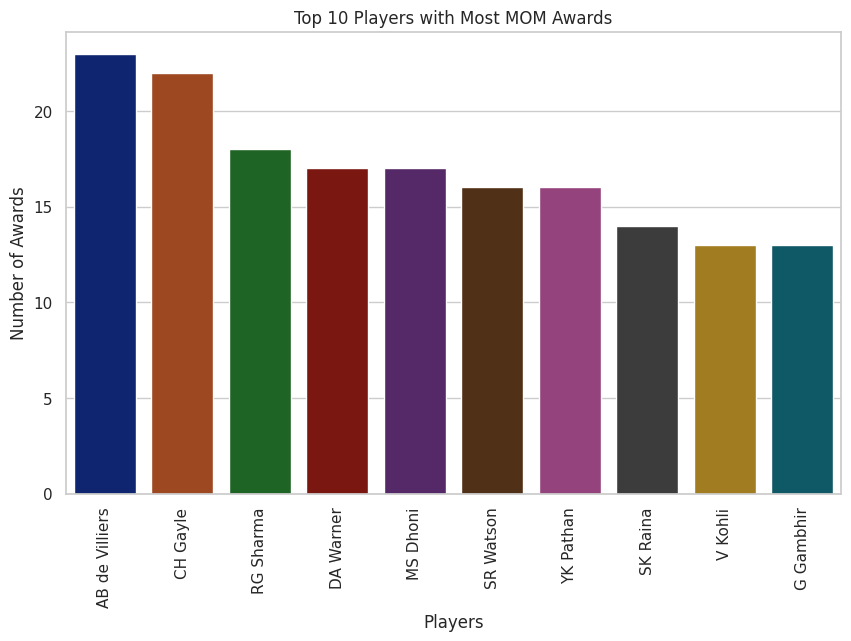

In [ ]:
#Q27.Who has won the most MOM awards?
##ANSWER:-
mom_awards = matches_df['player_of_match'].value_counts().reset_index()
mom_awards.columns = ['player','awards']
mom_awards = mom_awards.sort_values(by='awards', ascending=False)
mom_awards.head(11)
sns.barplot(x=mom_awards['player'].head(10),y=mom_awards['awards'].head(10),palette='dark',hue=mom_awards['player'].head(10),legend=False)
plt.title('Top 10 Players with Most MOM Awards')
plt.xlabel('Players')
plt.ylabel('Number of Awards')
plt.xticks(rotation=90)
plt.show()

    season  Fours
0     2008   1703
1     2009   1317
2     2010   1708
3     2011   1916
4     2012   1911
5     2013   2052
6     2014   1562
7     2015   1607
8     2016   1633
9     2017   1611
10    2018   1652
11    2019   1653
12    2020   1583


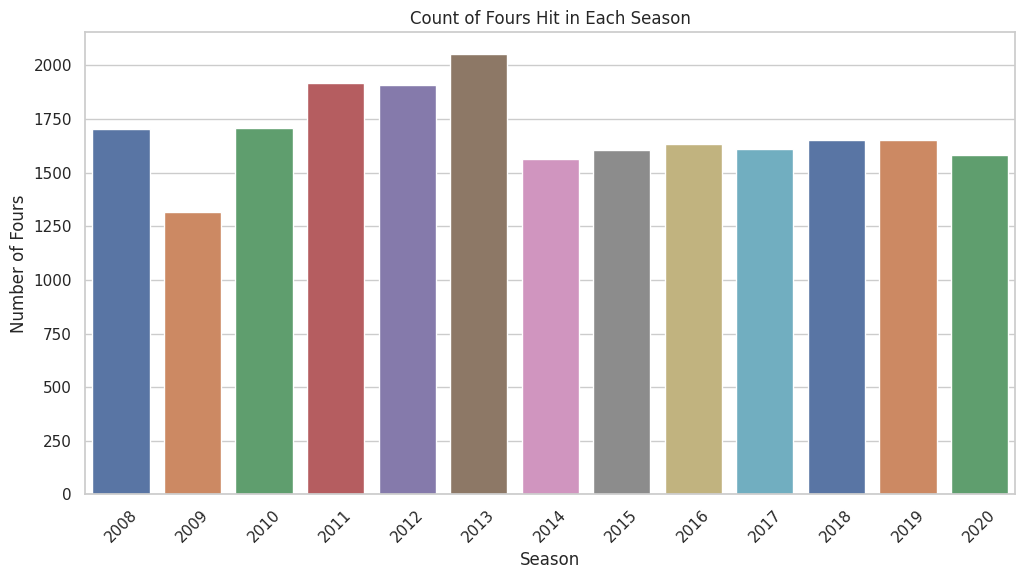

In [ ]:
#Q28.What is the count of fours hit in each season?
##ANSWER:-
fours = balls_df[balls_df['batsman_runs'] == 4]

fours_per_season = (
    fours.merge(matches_df[['id', 'season']], on='id')
         .groupby('season')
         .size()
         .reset_index(name='Fours')
)

print(fours_per_season)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=fours_per_season, x='season', y='Fours', palette='deep',hue='season',legend=False)

plt.title('Count of Fours Hit in Each Season')
plt.xlabel('Season')
plt.ylabel('Number of Fours')
plt.xticks(rotation=45)
plt.show()

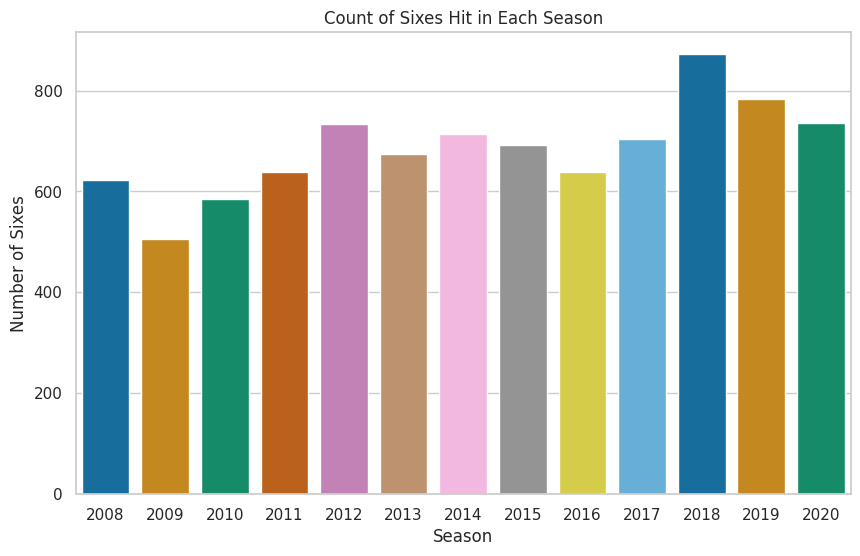

In [ ]:
#Q29.What is the count of sixes hit in each season?
##ANSWER:-
sixes = balls_df[balls_df['batsman_runs'] == 6]
sixes_per_season = (
    sixes.merge(matches_df[['id', 'season']], on='id')
         .groupby('season')
         .size()
         .reset_index(name='sixes')
)
sixes_per_season
sns.barplot(x=sixes_per_season['season'],y=sixes_per_season['sixes'],palette='colorblind',hue=sixes_per_season['season'],legend=False)
plt.title('Count of Sixes Hit in Each Season')
plt.xlabel('Season')
plt.ylabel('Number of Sixes')
plt.show()

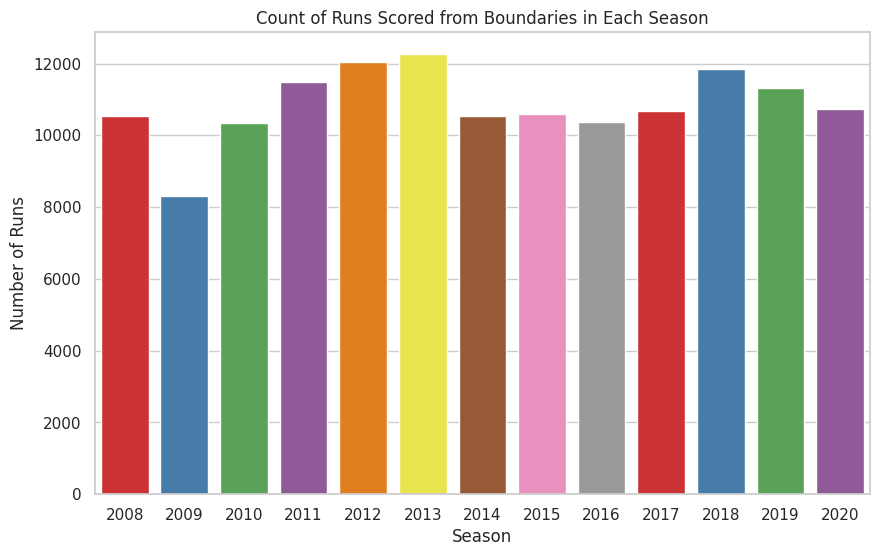

In [ ]:
#Q30.What is the count of runs scored from boundaries in each season?
##ANSWER:-
boundaries = balls_df[(balls_df['batsman_runs'] == 4) | (balls_df['batsman_runs'] == 6)]

boundary_runs = (
    boundaries.merge(matches_df[['id', 'season']], on='id')
              .groupby('season')['batsman_runs']
              .sum()
              .reset_index(name='Boundary_Runs')
)

boundary_runs
sns.barplot(x=boundary_runs['season'],y=boundary_runs['Boundary_Runs'],palette='Set1',hue=boundary_runs['season'],legend=False)
plt.title('Count of Runs Scored from Boundaries in Each Season')
plt.xlabel('Season')
plt.ylabel('Number of Runs')
plt.show()

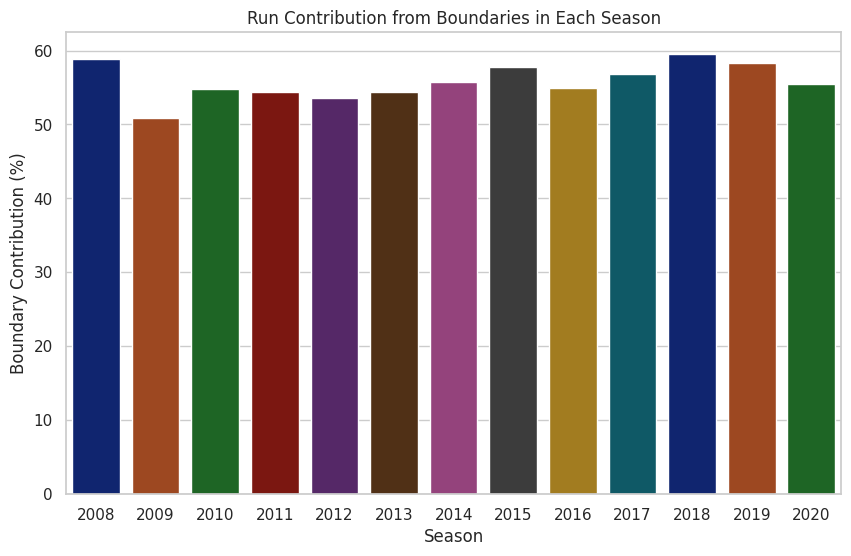

In [ ]:
#Q31.What is the run contribution from boundaries in each season?
##ANSWER:-
balls_season = balls_df.merge(matches_df[['id', 'season']], on='id')
total_runs = (
    balls_season.groupby('season')['total_runs']
                .sum()
                .reset_index(name='Total_Runs')
)
boundary_runs = (
    balls_season[balls_season['batsman_runs'].isin([4, 6])]
                .groupby('season')['batsman_runs']
                .sum()
                .reset_index(name='Boundary_Runs')
)
boundary_contribution = total_runs.merge(boundary_runs, on='season')
boundary_contribution['Boundary_Contribution (%)'] = (
    boundary_contribution['Boundary_Runs']
    / boundary_contribution['Total_Runs']
) * 100
boundary_contribution
sns.barplot(x=boundary_contribution['season'],y=boundary_contribution['Boundary_Contribution (%)'],palette='dark',hue=boundary_contribution['season'],legend=False)
plt.title('Run Contribution from Boundaries in Each Season')
plt.xlabel('Season')
plt.ylabel('Boundary Contribution (%)')
plt.show()

/tmp/ipykernel_470/2808829901.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


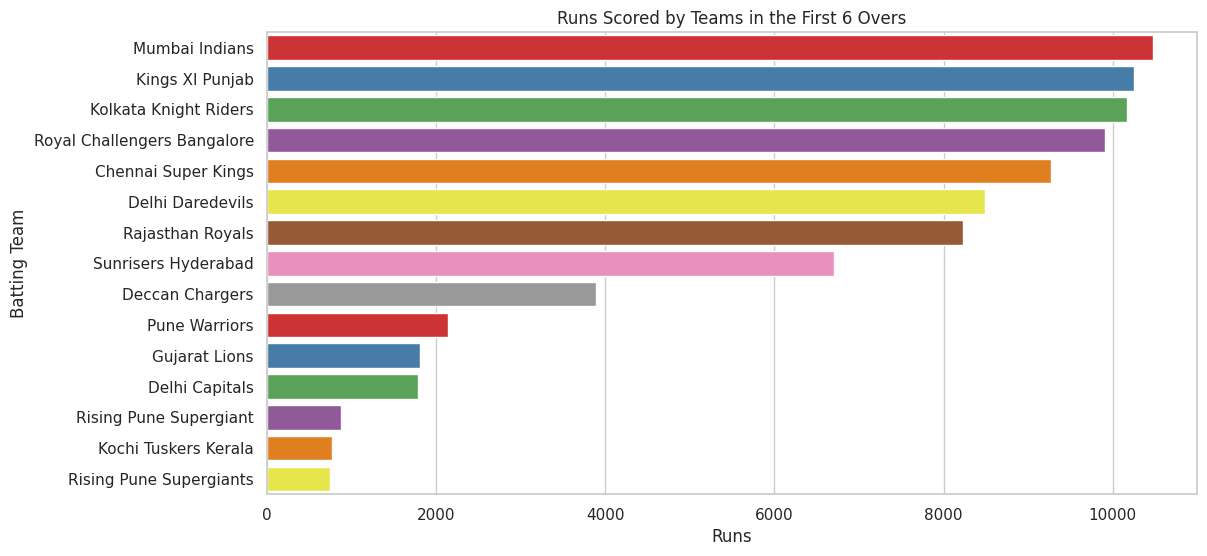

In [ ]:
#Q32.Which team has scored the most runs in the first 6 overs?
##ANSWER:-
powerplay_runs = balls_df[balls_df['over'] <= 6]

team_powerplay_runs = (
    powerplay_runs.groupby('batting_team')['total_runs']
                  .sum()
                  .reset_index(name='Powerplay_Runs')
                  .sort_values(by='Powerplay_Runs', ascending=False)
)

team_powerplay_runs.head(1)

plt.figure(figsize=(12,6))

sns.barplot(
    data=team_powerplay_runs,
    x='Powerplay_Runs',
    y='batting_team',
    palette='Set1'
)

plt.title('Runs Scored by Teams in the First 6 Overs')
plt.xlabel('Runs')
plt.ylabel('Batting Team')

plt.show()

     batting_team  Death_Over_Runs
8  Mumbai Indians             5708


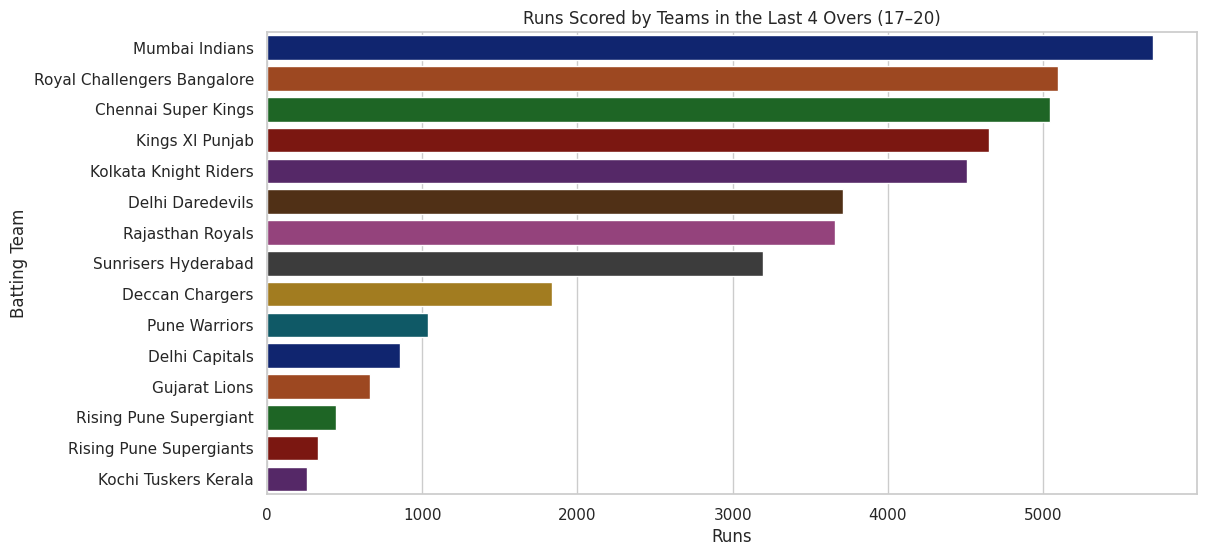

In [ ]:
#Q33.Which team has scored the most runs in the last 4 overs?
##ANSWER:-
death_overs = balls_df[balls_df['over'] >= 17]

team_death_runs = (
    death_overs.groupby('batting_team')['total_runs']
               .sum()
               .reset_index(name='Death_Over_Runs')
               .sort_values(by='Death_Over_Runs', ascending=False)
)

print(team_death_runs.head(1))

plt.figure(figsize=(12,6))

sns.barplot(
    data=team_death_runs,
    x='Death_Over_Runs',
    y='batting_team',
    palette='dark',
    hue='batting_team',
    legend=False
)

plt.title('Runs Scored by Teams in the Last 4 Overs (17–20)')
plt.xlabel('Runs')
plt.ylabel('Batting Team')

plt.show()

    batting_team  Total_Runs  Balls       Overs  Run_Rate
4  Gujarat Lions        1812   1309  218.166667  8.305577


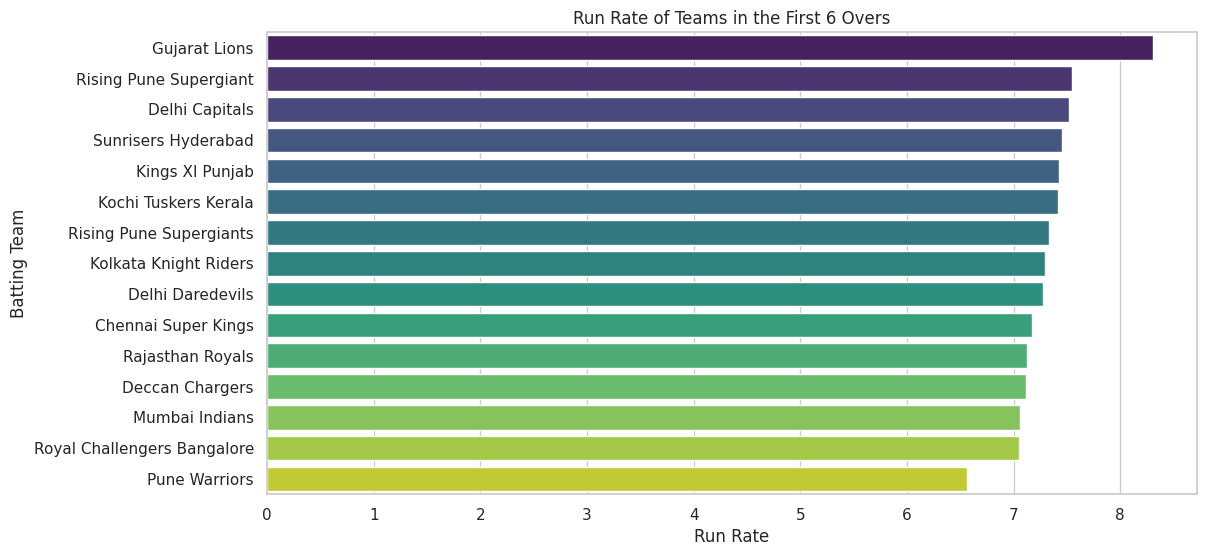

In [ ]:
#Q34.Which team has the best scoring run-rate in the first 6 overs?
##ANSWER:-
powerplay = balls_df[balls_df['over'] <= 6]

team_run_rate = (
    powerplay.groupby('batting_team')
             .agg(
                 Total_Runs=('total_runs', 'sum'),
                 Balls=('ball', 'count')
             )
             .reset_index()
)

team_run_rate['Overs'] = team_run_rate['Balls'] / 6
team_run_rate['Run_Rate'] = team_run_rate['Total_Runs'] / team_run_rate['Overs']

team_run_rate = team_run_rate.sort_values(by='Run_Rate', ascending=False)

print(team_run_rate.head(1))

plt.figure(figsize=(12,6))

sns.barplot(
    data=team_run_rate,
    x='Run_Rate',
    y='batting_team',
    palette='viridis',
    hue='batting_team',
    legend=False
)

plt.title('Run Rate of Teams in the First 6 Overs')
plt.xlabel('Run Rate')
plt.ylabel('Batting Team')

plt.show()

               batting_team  Total_Runs  Balls  Overs   Run_Rate
12  Rising Pune Supergiants         330    186   31.0  10.645161


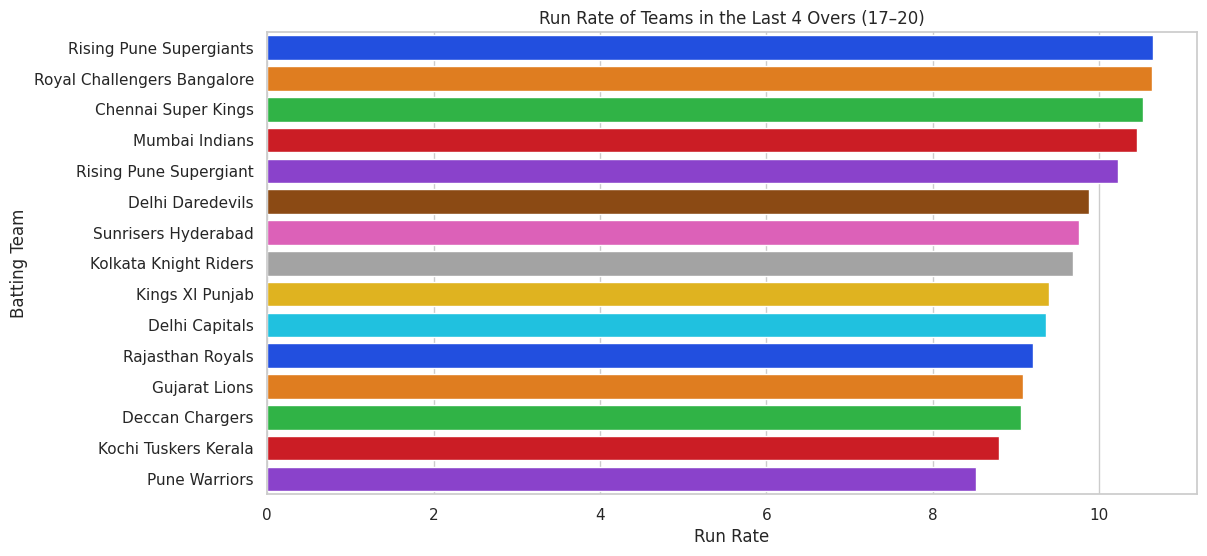

In [ ]:
#Q35.Which team has the best scoring run-rate in the last 4 overs?
##ANSWER:-
death_overs = balls_df[balls_df['over'] >= 17]

team_run_rate = (
    death_overs.groupby('batting_team')
               .agg(
                   Total_Runs=('total_runs', 'sum'),
                   Balls=('ball', 'count')
               )
               .reset_index()
)

team_run_rate['Overs'] = team_run_rate['Balls'] / 6
team_run_rate['Run_Rate'] = team_run_rate['Total_Runs'] / team_run_rate['Overs']

team_run_rate = team_run_rate.sort_values(by='Run_Rate', ascending=False)

print(team_run_rate.head(1))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=team_run_rate,
    x='Run_Rate',
    y='batting_team',
    palette='bright',
    hue='batting_team',
    legend=False

)

plt.title('Run Rate of Teams in the Last 4 Overs (17–20)')
plt.xlabel('Run Rate')
plt.ylabel('Batting Team')

plt.show()